# Geoeconomic Pressure Analysis: Chokepoints analysis

This notebook allows to plot specifically the chokepoint analysis we did in addition to the replication of the "Geoeconomic Pressure", it plots either the HHI or the vulnerability of sectors / value chains and allows to determine if the sectors targeted present "chokepoints" characteristics.

In [10]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [11]:
def parse_llm_audits(input_csv, output_csv):
    """
    Parse and flatten structured LLM audit responses from a CSV dataset.

    Read the input CSV containing raw LLM responses. Extract nested JSON data,
    summaries, and evaluations using regular expressions. Clean the JSON strings
    by removing markdown formatting, parse them into dictionaries, and merge the
    extracted fields back into the main DataFrame. Export the resulting flattened
    dataset to a new CSV file.

    Args:
        input_csv (str): Path to the input CSV file.
        output_csv (str): Path to the output CSV file.
    """
    df = pd.read_csv(input_csv, encoding='latin-1')
    extracted_data = []

    for index, row in df.iterrows():
        text = str(row.get('mistral_audit_response', ''))
        row_data = {}

        if text.strip() not in ['', 'nan'] and not text.startswith('ERREUR'):
            json_match = re.search(r'<JSON>(.*?)</JSON>', text, re.DOTALL)
            summary_match = re.search(r'<SUMMARY>(.*?)</SUMMARY>', text, re.DOTALL)
            eval_match = re.search(r'<EVAL>(.*?)</EVAL>', text, re.DOTALL)

            json_str = json_match.group(1).strip() if json_match else text.strip()

            json_str = re.sub(r'^```json\s*', '', json_str)
            json_str = re.sub(r'^```\s*', '', json_str)
            json_str = re.sub(r'\s*```$', '', json_str)
            json_str = json_str.strip()

            start_idx = json_str.find('{')
            end_idx = json_str.rfind('}')

            if start_idx != -1 and end_idx != -1:
                json_str = json_str[start_idx:end_idx+1]
                try:
                    parsed = json.loads(json_str)
                    for k, v in parsed.items():
                        if str(v) != "NaN":
                            row_data[k] = v
                except ValueError:
                    pass

            if summary_match:
                row_data['summary'] = summary_match.group(1).strip()

            if eval_match:
                row_data['eval'] = eval_match.group(1).strip()

        extracted_data.append(row_data)

    df_extracted = pd.DataFrame(extracted_data, index=df.index)

    for col in df_extracted.columns:
        if col in df.columns:
            df[col] = df[col].astype(object)
            mask = df_extracted[col].notna()
            df.loc[mask, col] = df_extracted.loc[mask, col]
        else:
            df[col] = df_extracted[col]

    df.to_csv(output_csv, index=False, encoding='utf-8')

parse_llm_audits('../Data/results_final_flattened_0.csv', 'outputs/output.csv')

In [12]:
df = pd.read_csv('outputs/output.csv', encoding='utf-8')
df.head()

,company,year,quarter,tariffs_summary,tariffs_effect_any,tariffs_effect_current,tariffs_effect_future,tariffs_investment_up_imposing,tariffs_investment_up_receiving,tariffs_investment_up_third_party,...,exports_correction,tariffs_hs_chapter_explanation,tariffs_hs_heading_explanation,tariffs_hs_subheading_explanation,sanctions_hs_chapter_explanation,sanctions_hs_heading_explanation,sanctions_hs_subheading_explanation,exports_hs_chapter_explanation,exports_hs_heading_explanation,exports_hs_subheading_explanation
0,Apple Inc. (AAPL),2025.0,Q1,[Part 5] Apple is monitoring the situation reg...,1.0,0.0,1.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Apple Inc. (AAPL),2025.0,Q3,"[Part 1] Apple is affected by tariffs, with es...",1.0,1.0,1.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Microsoft Corporation (MSFT),2025.0,Q1,Not affected.,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Microsoft Corporation (MSFT),2025.0,Q2,[Part 3] Microsoft's Windows OEM revenue may b...,1.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Microsoft Corporation (MSFT),2025.0,Q4,Not affected.,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


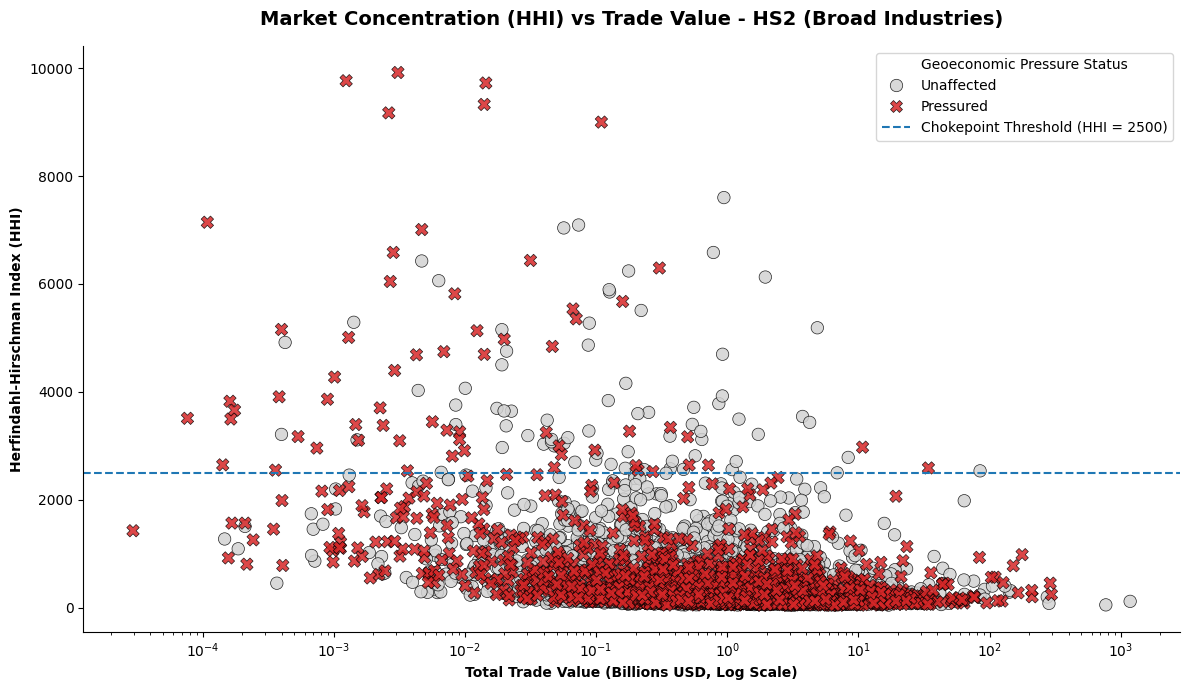

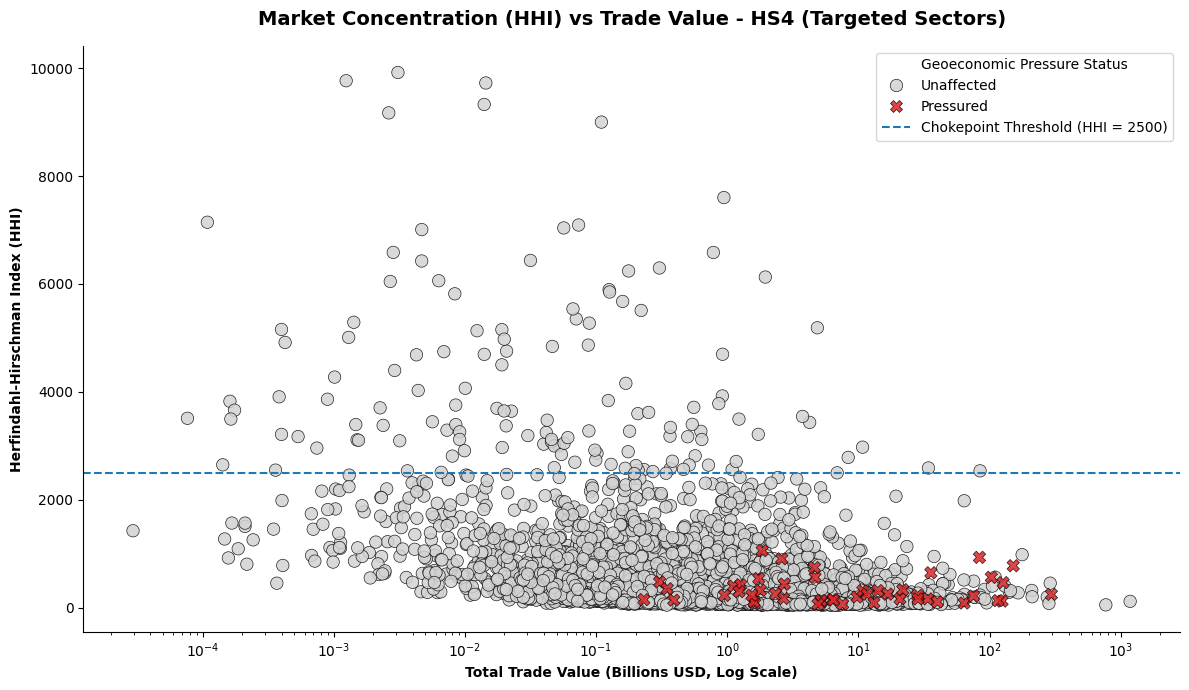

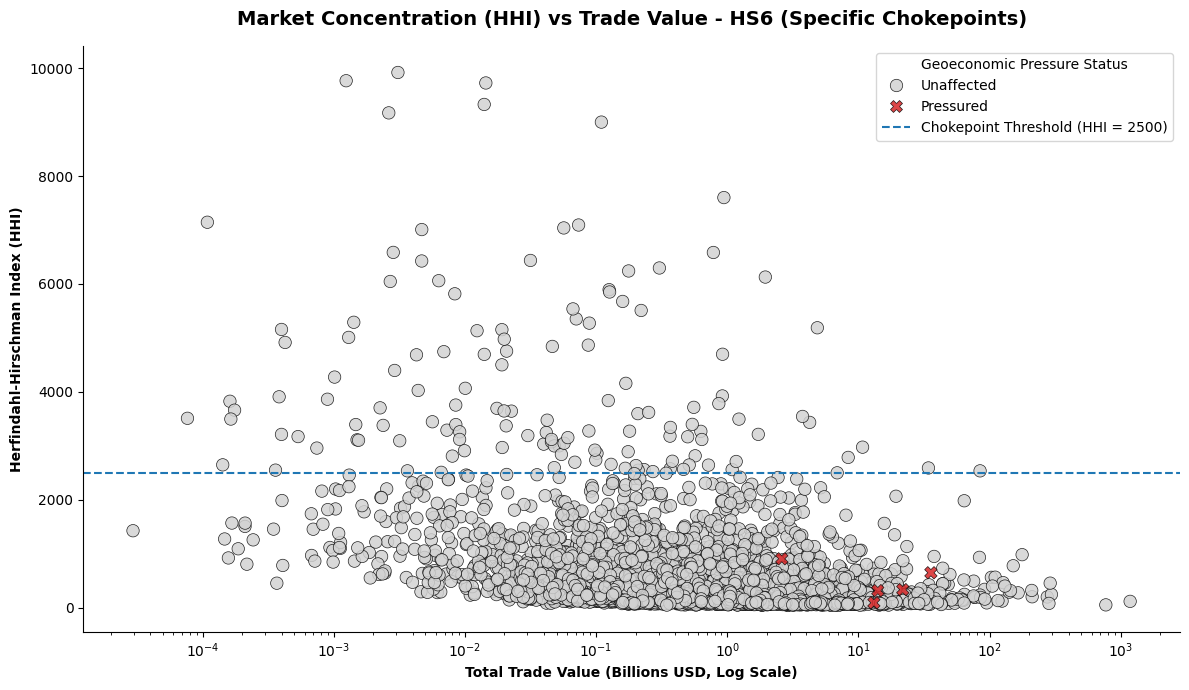

In [13]:
def calculate_hhi(market_values):
    """
    Calculate the Herfindahl-Hirschman Index (HHI) for a specific product market.
    
    Args:
        market_values (pd.Series): The trade values of all exporters for a product.
        
    Returns:
        float: The calculated HHI (sum of squared market shares).
    """
    shares = (market_values / market_values.sum()) * 100
    return (shares ** 2).sum()


def visualize_trade_chokepoints(baci_df, countries_df, hs_df, hs_iu_df, pressure_df):
    """
    Identify and visualize geoeconomic chokepoints using the Herfindahl-Hirschman Index.

    Merge global bilateral trade data (BACI) with product classification codes (HS)
    and LLM-extracted geoeconomic pressure flags. Calculate market concentration (HHI) 
    for each product and generate scatterplots to highlight highly concentrated 
    markets (chokepoints) currently under trade restrictions.

    Args:
        baci_df (pd.DataFrame): Global bilateral trade flows.
        countries_df (pd.DataFrame): Standardized country codes and ISO3 mappings.
        hs_df (pd.DataFrame): Harmonized System (HS) product codes and descriptions.
        hs_iu_df (pd.DataFrame): Concordance mapping between HS and Industry classifications.
        pressure_df (pd.DataFrame): Processed geoeconomic pressures with LLM audits.

    Returns:
        None
    """
    # Clean and isolate valid audit responses
    df_pressure = pressure_df[pressure_df['mistral_audit_response'].notna()].copy()
    df_pressure = df_pressure[
        ~df_pressure['mistral_audit_response'].astype(str).str.startswith('ERREUR')
    ]

    # Standardize HS codes to 6 digits with leading zeros
    baci_df['k_str'] = baci_df['k'].astype(str).str.zfill(6)
    hs_df['code_str'] = hs_df['code'].astype(str).str.zfill(6)

    hs_code_col_iu = [c for c in hs_iu_df.columns if 'hs' in c.lower() or 'code' in c.lower()][0]
    hs_iu_df['hs_str'] = hs_iu_df[hs_code_col_iu].astype(str).str.zfill(6)

    # Merge trade flows with exporter and importer metadata
    df = baci_df.merge(
        countries_df[['country_code', 'country_name', 'country_iso3']], 
        left_on='i', right_on='country_code', how='left'
    ).rename(
        columns={'country_name': 'exporter_name', 'country_iso3': 'exporter_iso3'}
    ).drop(columns=['country_code'])

    df = df.merge(
        countries_df[['country_code', 'country_name', 'country_iso3']], 
        left_on='j', right_on='country_code', how='left'
    ).rename(
        columns={'country_name': 'importer_name', 'country_iso3': 'importer_iso3'}
    ).drop(columns=['country_code'])

    # Merge product descriptions and concordance metrics
    df = df.merge(
        hs_df[['code_str', 'description']], 
        left_on='k_str', right_on='code_str', how='left'
    ).drop(columns=['code_str'])

    iu_cols = [c for c in hs_iu_df.columns if c not in (hs_code_col_iu, 'hs_str')]
    df = df.merge(
        hs_iu_df[['hs_str'] + iu_cols], 
        left_on='k_str', right_on='hs_str', how='left'
    ).drop(columns=['hs_str'])

    baci_unique_codes = df['k_str'].unique()

    # Extract targeted HS codes from the text descriptions of trade pressures
    hs2_codes, hs4_codes, hs6_codes = set(), set(), set()
    hs_cols = [c for c in df_pressure.columns if 'hs_' in c and 'explanation' not in c]

    for col in hs_cols:
        vals = df_pressure[col].dropna().astype(str).str.strip()
        for v_item in vals:
            if v_item.lower() not in ['nan', 'none', 'null', '']:
                for code_part in v_item.split(','):
                    match = re.search(r'(\d+[\.\d]*)', code_part)
                    if match:
                        raw_code = match.group(1).replace('.', '')
                        if len(raw_code) == 1:
                            raw_code = '0' + raw_code
                        
                        if len(raw_code) == 2:
                            hs2_codes.add(raw_code)
                        elif 3 <= len(raw_code) <= 4:
                            hs4_codes.add(raw_code.zfill(4))
                        elif len(raw_code) >= 5:
                            hs6_codes.add(raw_code[:6].zfill(6))

    # Identify BACI trade codes impacted by pressures at various aggregation levels
    baci_under_hs2 = {b for b in baci_unique_codes if any(b.startswith(c) for c in hs2_codes)}
    baci_under_hs4 = {b for b in baci_unique_codes if any(b.startswith(c) for c in hs4_codes)}
    baci_under_hs6 = {b for b in baci_unique_codes if any(b.startswith(c) for c in hs6_codes)}

    # Calculate HHI concentration index per product (Operating on 'v' avoids groupby apply warnings)
    hhi_per_product = df.groupby(
        ['k_str', 'description']
    )['v'].apply(calculate_hhi).reset_index(name='hhi')
    
    hhi_with_val = hhi_per_product.merge(
        df.groupby('k_str')['v'].sum().reset_index(), on='k_str'
    )
    hhi_with_val['v_billion'] = hhi_with_val['v'] / 1e6

    aggregation_scales = {
        'HS2 (Broad Industries)': (baci_under_hs2, 'HS2'),
        'HS4 (Targeted Sectors)': (baci_under_hs4, 'HS4'),
        'HS6 (Specific Chokepoints)': (baci_under_hs6, 'HS6')
    }

    # Plot generation loop for each aggregation scale
    for title, (code_set, file_suffix) in aggregation_scales.items():
        if not code_set:
            continue
            
        df_plot = hhi_with_val.copy()
        df_plot['is_under_pressure'] = df_plot['k_str'].isin(code_set)
        df_plot['Status'] = np.where(df_plot['is_under_pressure'], 'Pressured', 'Unaffected')
        df_plot = df_plot.sort_values(by='is_under_pressure')
        
        plt.figure(figsize=(12, 7))
        sns.scatterplot(
            data=df_plot, 
            x='v_billion', 
            y='hhi', 
            hue='Status', 
            style='Status',
            palette={'Pressured': '#d62728', 'Unaffected': '#d3d3d3'}, 
            markers={'Pressured': 'X', 'Unaffected': 'o'},
            alpha=0.85,
            s=80,
            edgecolor='black',
            linewidth=0.5
        )
        
        plt.axhline(2500, color='#1f77b4', linestyle='--', linewidth=1.5, label='Chokepoint Threshold (HHI = 2500)')
        plt.xscale('log')
        plt.title(f'Market Concentration (HHI) vs Trade Value - {title}', fontsize=14, fontweight='bold', pad=15)
        plt.xlabel('Total Trade Value (Billions USD, Log Scale)', fontweight='bold')
        plt.ylabel('Herfindahl-Hirschman Index (HHI)', fontweight='bold')
        
        plt.legend(title='Geoeconomic Pressure Status', loc='upper right')
        
        # Despine and clean layout for a professional aesthetic
        sns.despine()
        plt.tight_layout()
        plt.savefig(f'chokepoints_hhi_{file_suffix}.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()

baci_df = pd.read_csv('../Data/BACI_HS17_Y2018_V202601.csv', encoding='latin-1')

countries_df = pd.read_csv('../Data/country_codes_V202601.csv', encoding='latin-1')

hs_df = pd.read_csv('../Data/product_codes_HS17_V202601.csv', encoding='latin-1')

hs_iu_df = pd.read_csv('../Data/JobID-65_Concordance_HS_to_IU.csv', encoding='latin-1')

pressure_df = pd.read_csv('../Data/results_final_flattened_0.csv', encoding='latin-1')



pressure_df = pressure_df[pressure_df['mistral_audit_response'].notna()]

pressure_df = pressure_df[~pressure_df['mistral_audit_response'].astype(str).str.startswith('ERREUR')]



baci_df['k_str'] = baci_df['k'].astype(str).str.zfill(6)

hs_df['code_str'] = hs_df['code'].astype(str).str.zfill(6)



hs_code_col_iu = [c for c in hs_iu_df.columns if 'hs' in c.lower() or 'code' in c.lower()][0]

hs_iu_df['hs_str'] = hs_iu_df[hs_code_col_iu].astype(str).str.zfill(6)

iu_code_col_iu = [c for c in hs_iu_df.columns if 'iu' in c.lower() or 'code' in c.lower()][0]

hs_iu_df['iu_str'] = hs_iu_df[iu_code_col_iu].astype(str).str.zfill(6)

visualize_trade_chokepoints(baci_df,countries_df, hs_df, hs_iu_df, pressure_df)

/var/folders/0w/lf6hd86155sgzz5x85l_z4wm0000gn/T/ipykernel_90971/306416488.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  us_import_hhi_df = us_imports.groupby('k_str').apply(calculate_market_hhi).reset_index(name='us_import_hhi')


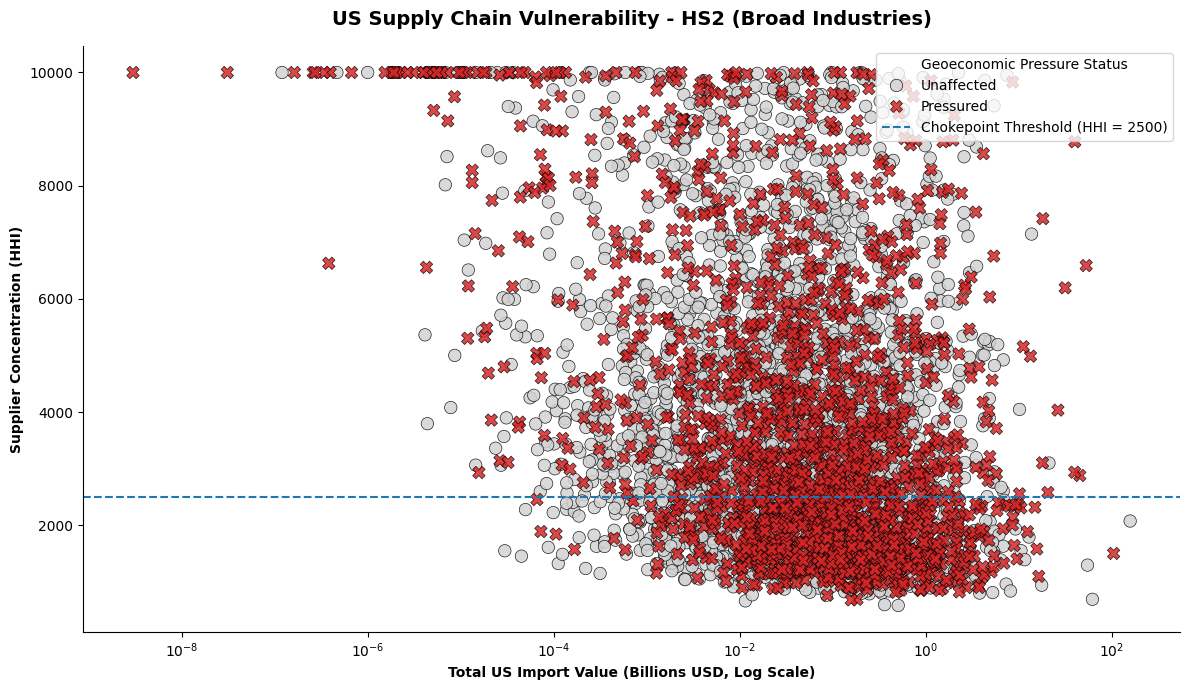

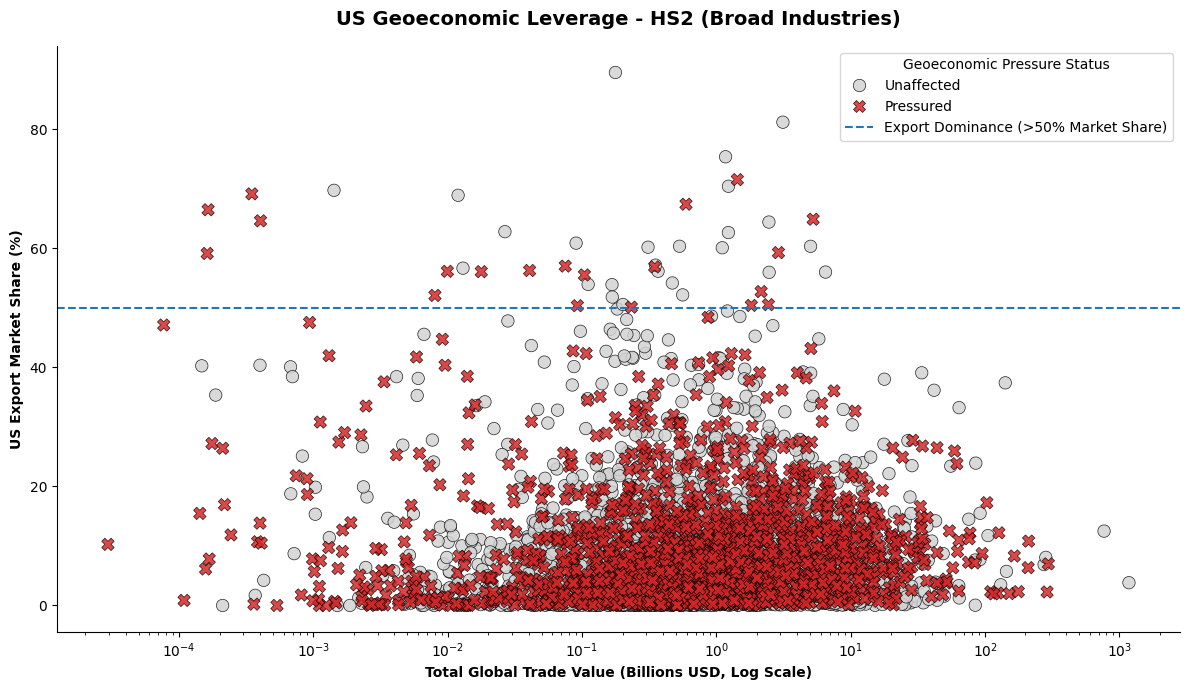

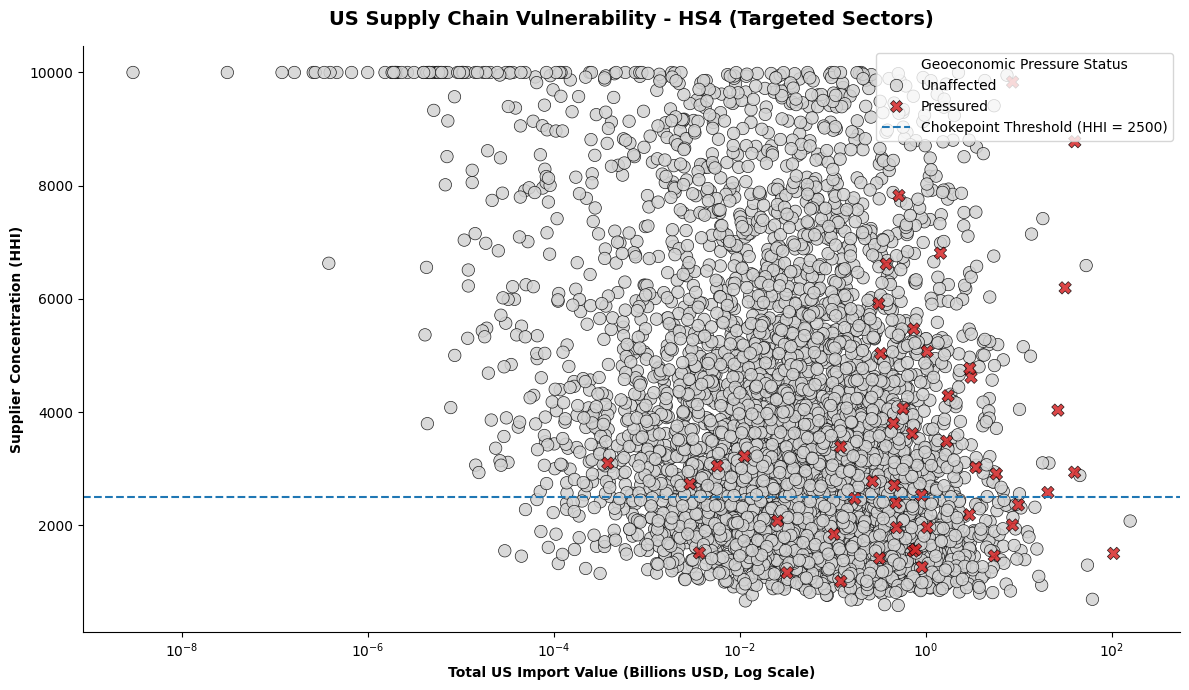

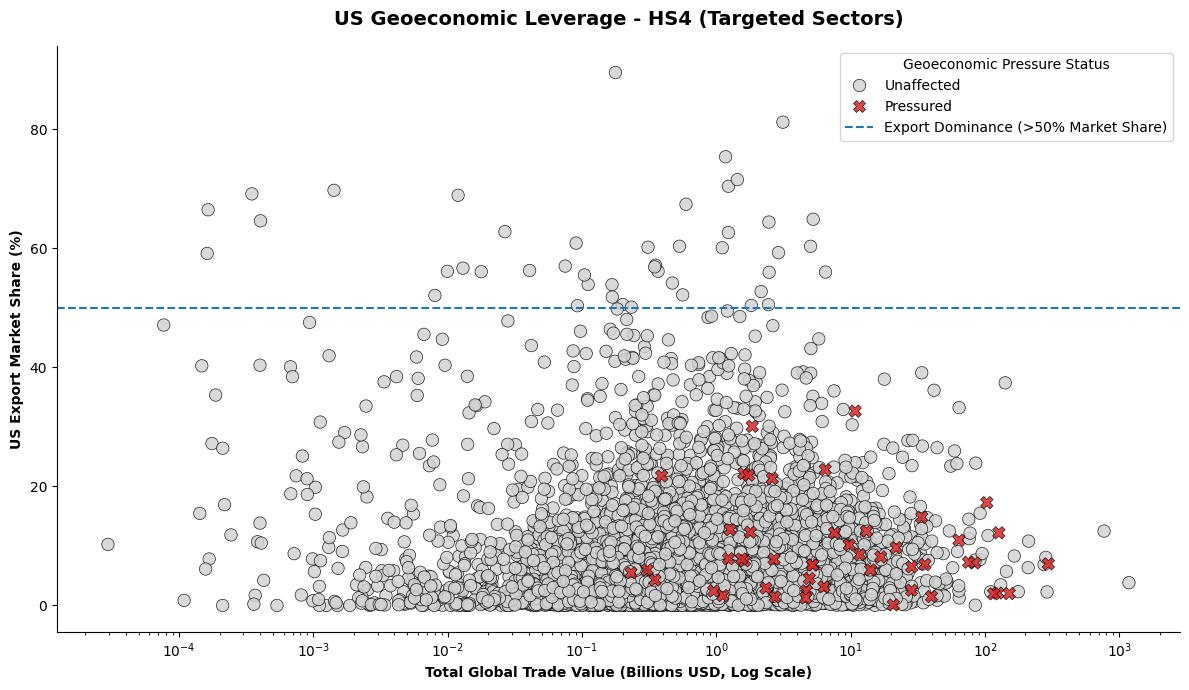

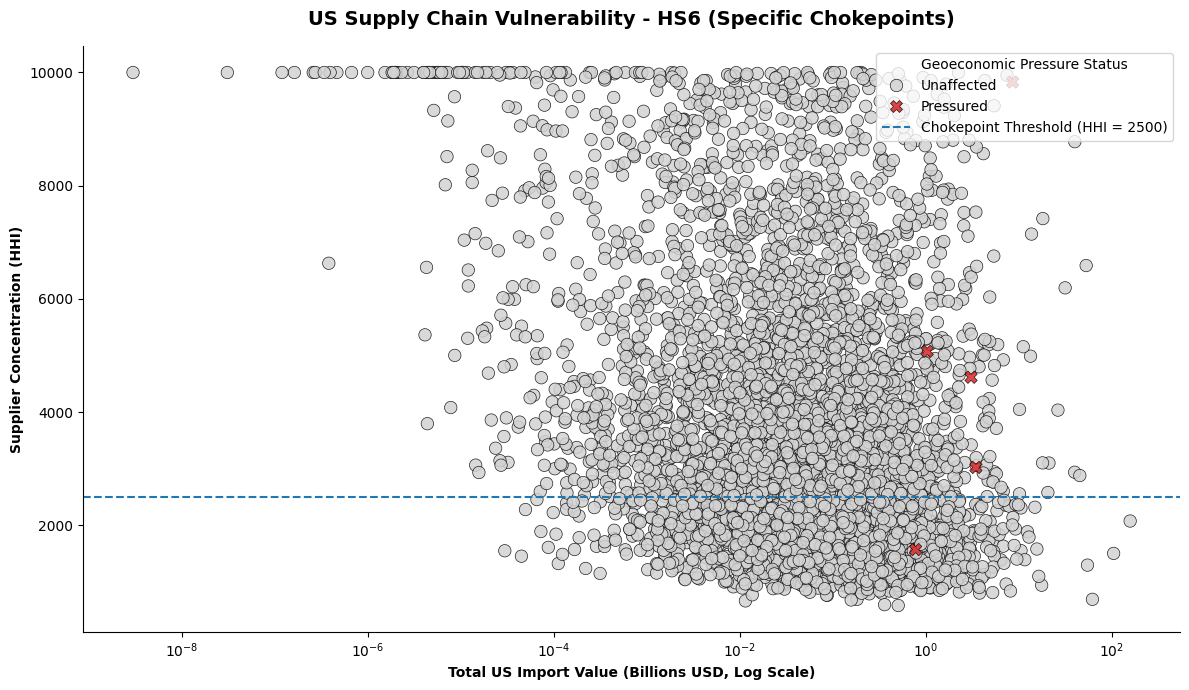

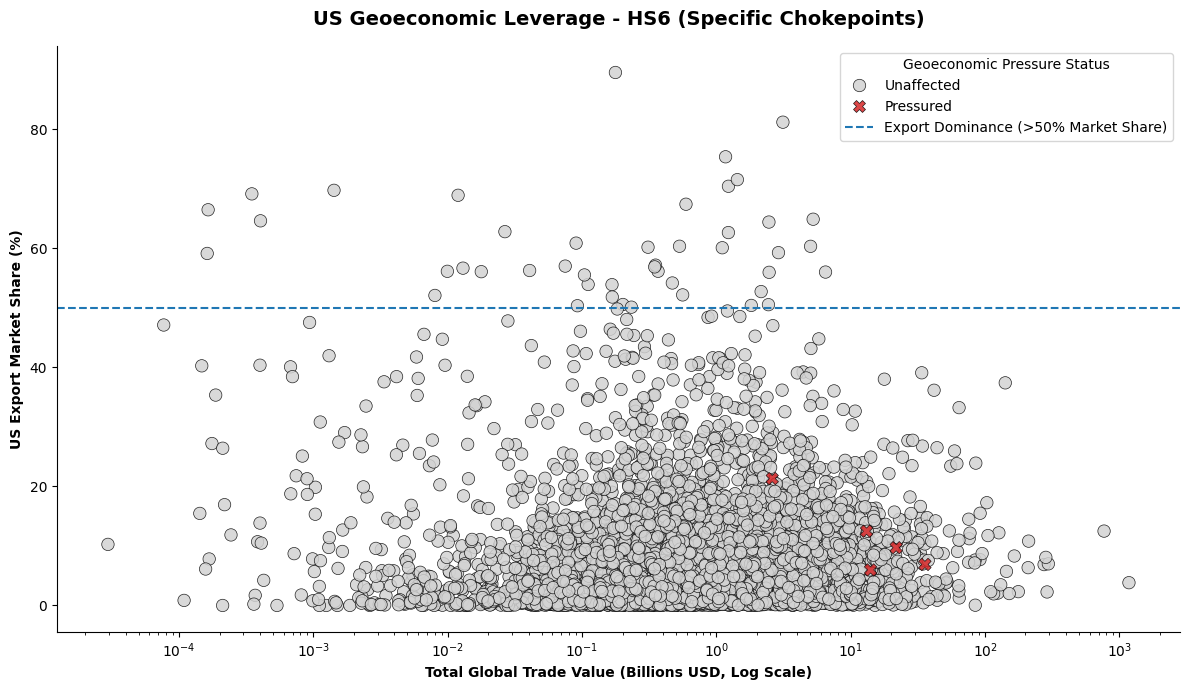

In [15]:
def calculate_market_hhi(group):
    """
    Calculate the Herfindahl-Hirschman Index (HHI) for a grouped market DataFrame.

    Args:
        group (pd.DataFrame): Grouped dataframe containing a 'v' column for trade values.

    Returns:
        float: The calculated HHI score.
    """
    shares = (group['v'] / group['v'].sum()) * 100
    return (shares ** 2).sum()


def analyze_us_trade_vulnerability_and_leverage(baci_df, countries_df, pressure_df):
    """
    Analyze and visualize US supply chain vulnerability and geoeconomic leverage.

    Process global bilateral trade data and LLM-extracted geoeconomic pressures
    to identify targeted product categories at the HS2, HS4, and HS6 levels. 
    Calculate supplier concentration (HHI) for US imports to assess vulnerability, 
    and compute US export market shares to evaluate geoeconomic leverage. 
    Generate corresponding scatter plots for each aggregation scale.

    Args:
        baci_df (pd.DataFrame): Global bilateral trade flows.
        countries_df (pd.DataFrame): Standardized country codes and ISO3 mappings.
        pressure_df (pd.DataFrame): Processed geoeconomic pressures with LLM audits.

    Returns:
        None
    """
    df_pressure = pressure_df[pressure_df['mistral_audit_response'].notna()].copy()
    df_pressure = df_pressure[
        ~df_pressure['mistral_audit_response'].astype(str).str.startswith('ERREUR')
    ]

    baci_df['k_str'] = baci_df['k'].astype(str).str.zfill(6)

    us_code_row = countries_df[countries_df['country_iso3'] == 'USA']
    us_code = us_code_row['country_code'].iloc[0] if not us_code_row.empty else 840

    baci_unique_codes = baci_df['k_str'].unique()

    hs2_codes, hs4_codes, hs6_codes = set(), set(), set()
    hs_cols = [c for c in df_pressure.columns if 'hs_' in c and 'explanation' not in c]

    for col in hs_cols:
        vals = df_pressure[col].dropna().astype(str).str.strip()
        for v_item in vals:
            if v_item.lower() not in ['nan', 'none', 'null', '']:
                for code_part in v_item.split(','):
                    match = re.search(r'(\d+[\.\d]*)', code_part)
                    if match:
                        raw_code = match.group(1).replace('.', '')
                        if len(raw_code) == 1:
                            raw_code = '0' + raw_code
                        
                        if len(raw_code) == 2:
                            hs2_codes.add(raw_code)
                        elif 3 <= len(raw_code) <= 4:
                            hs4_codes.add(raw_code.zfill(4))
                        elif len(raw_code) >= 5:
                            hs6_codes.add(raw_code[:6].zfill(6))

    baci_under_hs2 = {b for b in baci_unique_codes if any(b.startswith(c) for c in hs2_codes)}
    baci_under_hs4 = {b for b in baci_unique_codes if any(b.startswith(c) for c in hs4_codes)}
    baci_under_hs6 = {b for b in baci_unique_codes if any(b.startswith(c) for c in hs6_codes)}

    aggregation_scales = {
        'HS2 (Broad Industries)': (baci_under_hs2, 'HS2'),
        'HS4 (Targeted Sectors)': (baci_under_hs4, 'HS4'),
        'HS6 (Specific Chokepoints)': (baci_under_hs6, 'HS6')
    }

    us_imports = baci_df[baci_df['j'] == us_code].copy()
    us_import_totals = us_imports.groupby('k_str')['v'].sum().reset_index(name='us_total_import')

    us_import_hhi_df = us_imports.groupby('k_str').apply(calculate_market_hhi).reset_index(name='us_import_hhi')
    base_us_import_analysis = us_import_totals.merge(us_import_hhi_df, on='k_str')
    base_us_import_analysis['v_billion'] = base_us_import_analysis['us_total_import'] / 1e6

    global_exports = baci_df.groupby('k_str')['v'].sum().reset_index(name='global_total_export')
    us_exports = baci_df[baci_df['i'] == us_code].groupby('k_str')['v'].sum().reset_index(name='us_export')
    base_us_export_analysis = global_exports.merge(us_exports, on='k_str', how='left').fillna({'us_export': 0})
    base_us_export_analysis['us_export_share_%'] = (base_us_export_analysis['us_export'] / base_us_export_analysis['global_total_export']) * 100
    base_us_export_analysis['global_v_billion'] = base_us_export_analysis['global_total_export'] / 1e6

    for title, (code_set, file_suffix) in aggregation_scales.items():
        if not code_set:
            continue

        us_import_analysis = base_us_import_analysis.copy()
        us_import_analysis['is_under_pressure'] = us_import_analysis['k_str'].isin(code_set)
        us_import_analysis['Status'] = np.where(us_import_analysis['is_under_pressure'], 'Pressured', 'Unaffected')
        us_import_analysis = us_import_analysis.sort_values(by='is_under_pressure')

        plt.figure(figsize=(12, 7))
        sns.scatterplot(
            data=us_import_analysis, 
            x='v_billion', 
            y='us_import_hhi', 
            hue='Status', 
            style='Status',
            palette={'Pressured': '#d62728', 'Unaffected': '#d3d3d3'}, 
            markers={'Pressured': 'X', 'Unaffected': 'o'},
            alpha=0.85,
            s=80,
            edgecolor='black',
            linewidth=0.5
        )
        
        plt.axhline(2500, color='#1f77b4', linestyle='--', linewidth=1.5, label='Chokepoint Threshold (HHI = 2500)')
        plt.xscale('log')
        plt.title(f'US Supply Chain Vulnerability - {title}', fontsize=14, fontweight='bold', pad=15)
        plt.xlabel('Total US Import Value (Billions USD, Log Scale)', fontweight='bold')
        plt.ylabel('Supplier Concentration (HHI)', fontweight='bold')
        plt.legend(title='Geoeconomic Pressure Status', loc='upper right')
        
        sns.despine()
        plt.tight_layout()
        plt.savefig(f'us_import_vulnerability_{file_suffix}.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()

        us_export_analysis = base_us_export_analysis.copy()
        us_export_analysis['is_under_pressure'] = us_export_analysis['k_str'].isin(code_set)
        us_export_analysis['Status'] = np.where(us_export_analysis['is_under_pressure'], 'Pressured', 'Unaffected')
        us_export_analysis = us_export_analysis.sort_values(by='is_under_pressure')

        plt.figure(figsize=(12, 7))
        sns.scatterplot(
            data=us_export_analysis, 
            x='global_v_billion', 
            y='us_export_share_%', 
            hue='Status', 
            style='Status',
            palette={'Pressured': '#d62728', 'Unaffected': '#d3d3d3'}, 
            markers={'Pressured': 'X', 'Unaffected': 'o'},
            alpha=0.85,
            s=80,
            edgecolor='black',
            linewidth=0.5
        )
        
        plt.axhline(50, color='#1f77b4', linestyle='--', linewidth=1.5, label='Export Dominance (>50% Market Share)')
        plt.xscale('log')
        plt.title(f'US Geoeconomic Leverage - {title}', fontsize=14, fontweight='bold', pad=15)
        plt.xlabel('Total Global Trade Value (Billions USD, Log Scale)', fontweight='bold')
        plt.ylabel('US Export Market Share (%)', fontweight='bold')
        plt.legend(title='Geoeconomic Pressure Status', loc='upper right')
        
        sns.despine()
        plt.tight_layout()
        plt.savefig(f'us_export_leverage_{file_suffix}.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()

analyze_us_trade_vulnerability_and_leverage(baci_df, countries_df, pressure_df)

Loading CSV files...
Loading complete.
Extracting customs codes from transcripts...
Codes found - Tariffs: HS2(14), HS4(2), HS6(8)
Codes found - Sanctions: HS2(2), HS4(1), HS6(1)
Codes found - Exports: HS2(2), HS4(3), HS6(3)

--- Aggregating and calculating HHI for: HS2 (Chapters - Entire Industries) ---
Displaying US Import Vulnerability plot (HS2_agg)


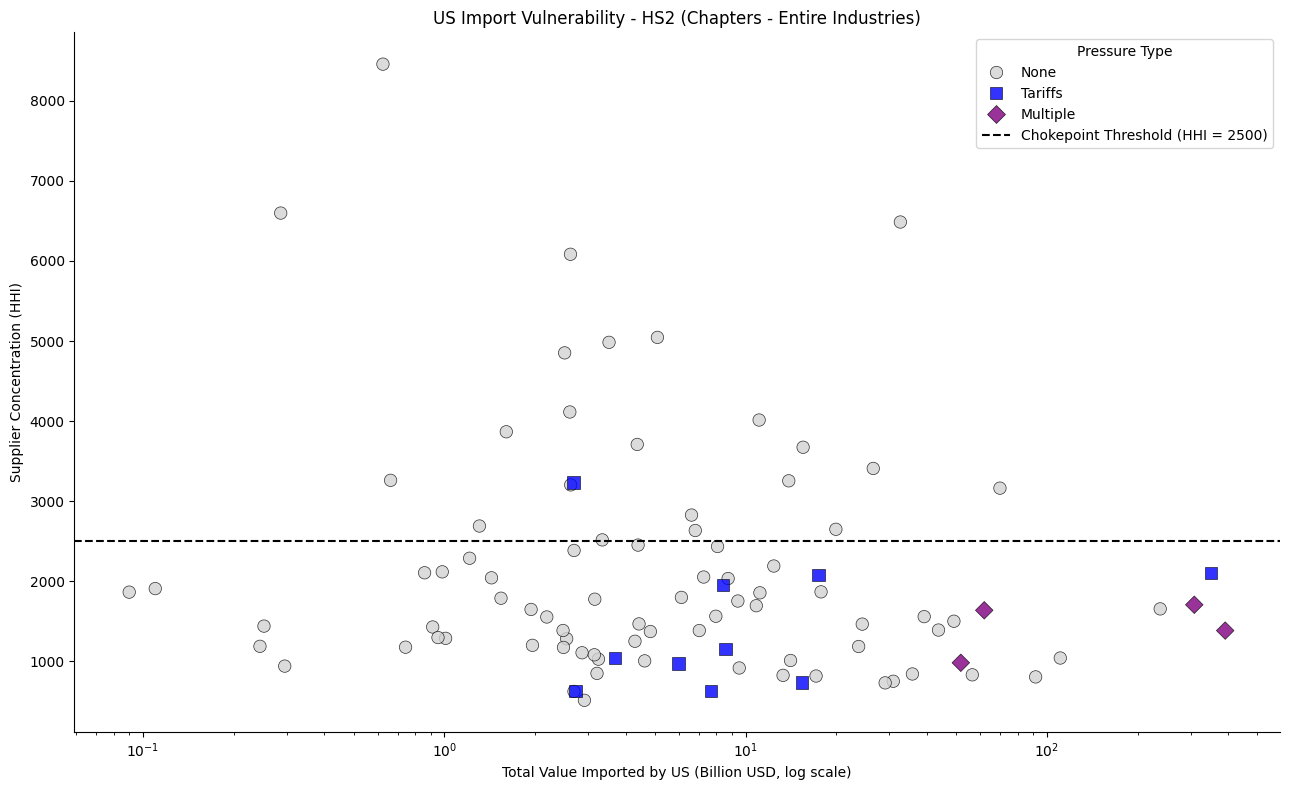

Displaying US Export Leverage plot (HS2_agg)


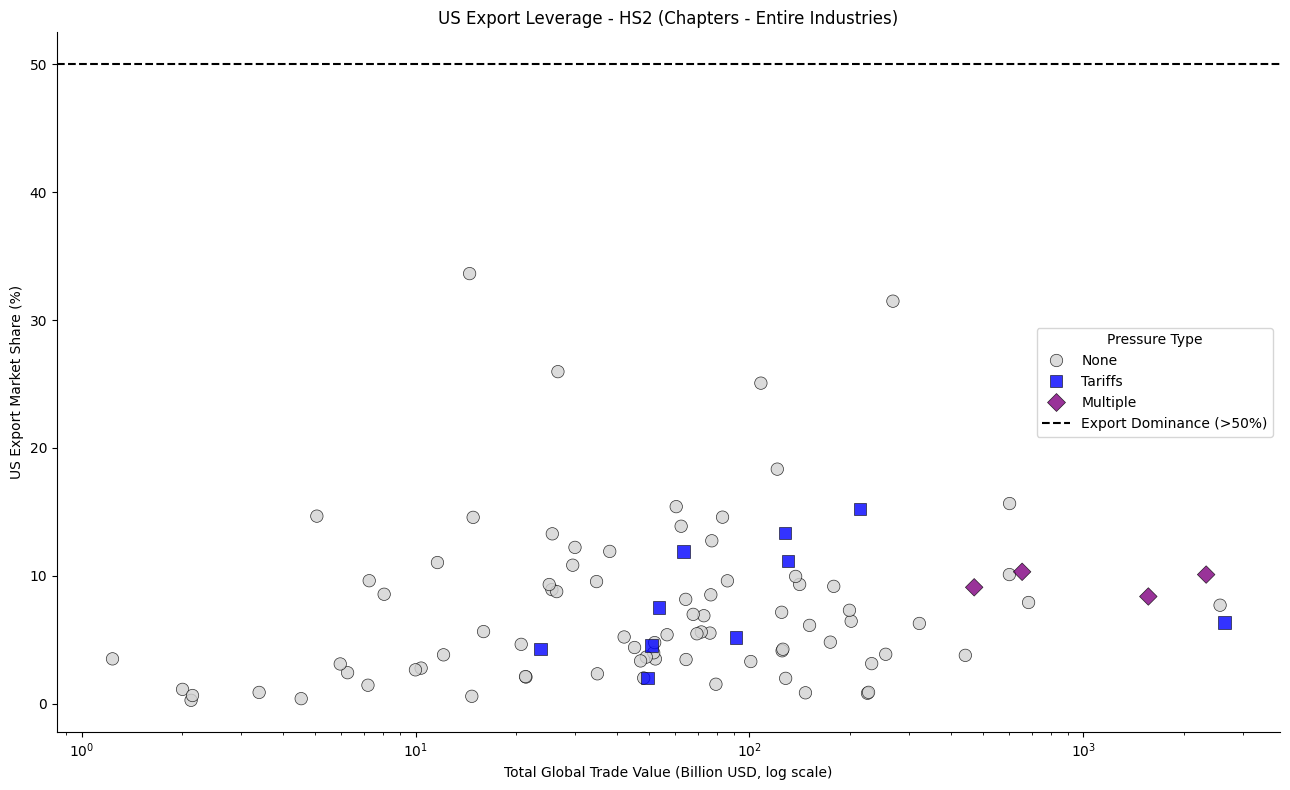


--- Aggregating and calculating HHI for: HS4 (Headings - Targeted Sectors) ---
Displaying US Import Vulnerability plot (HS4_agg)


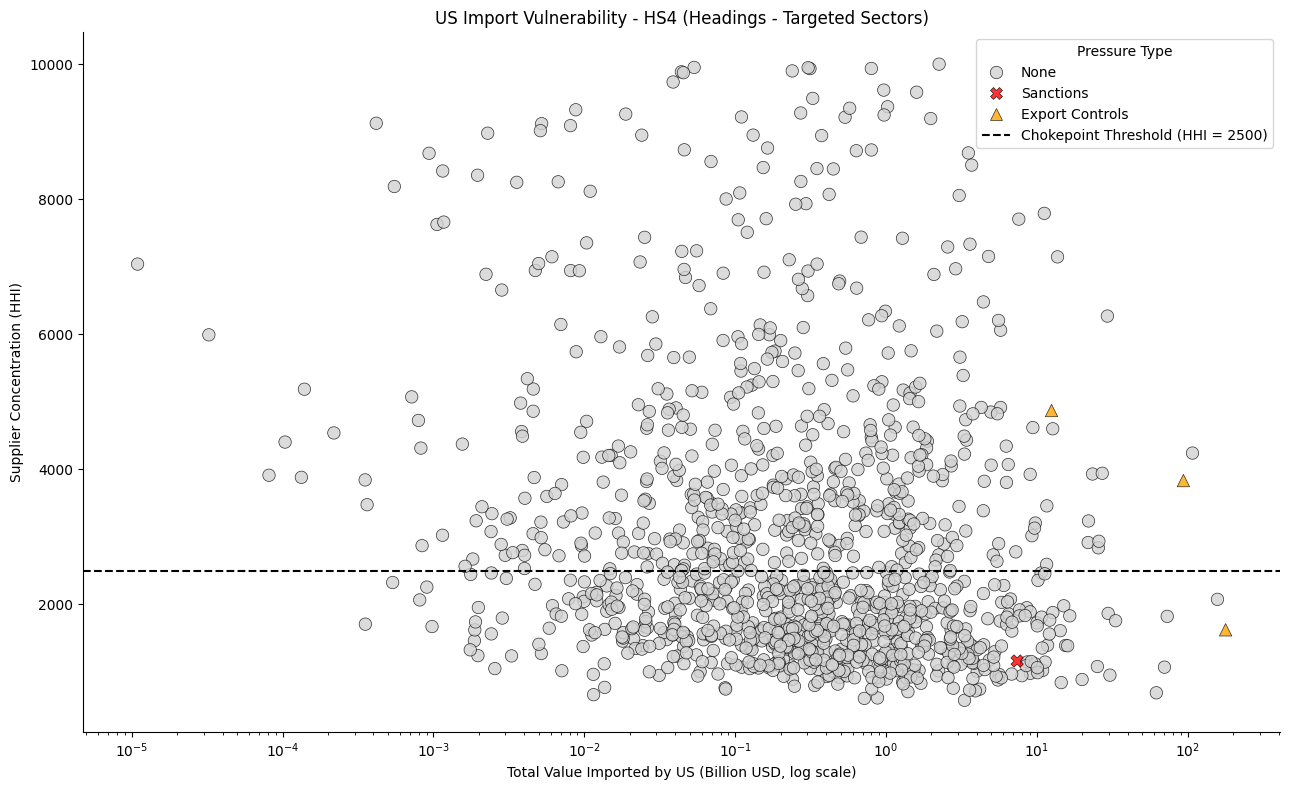

Displaying US Export Leverage plot (HS4_agg)


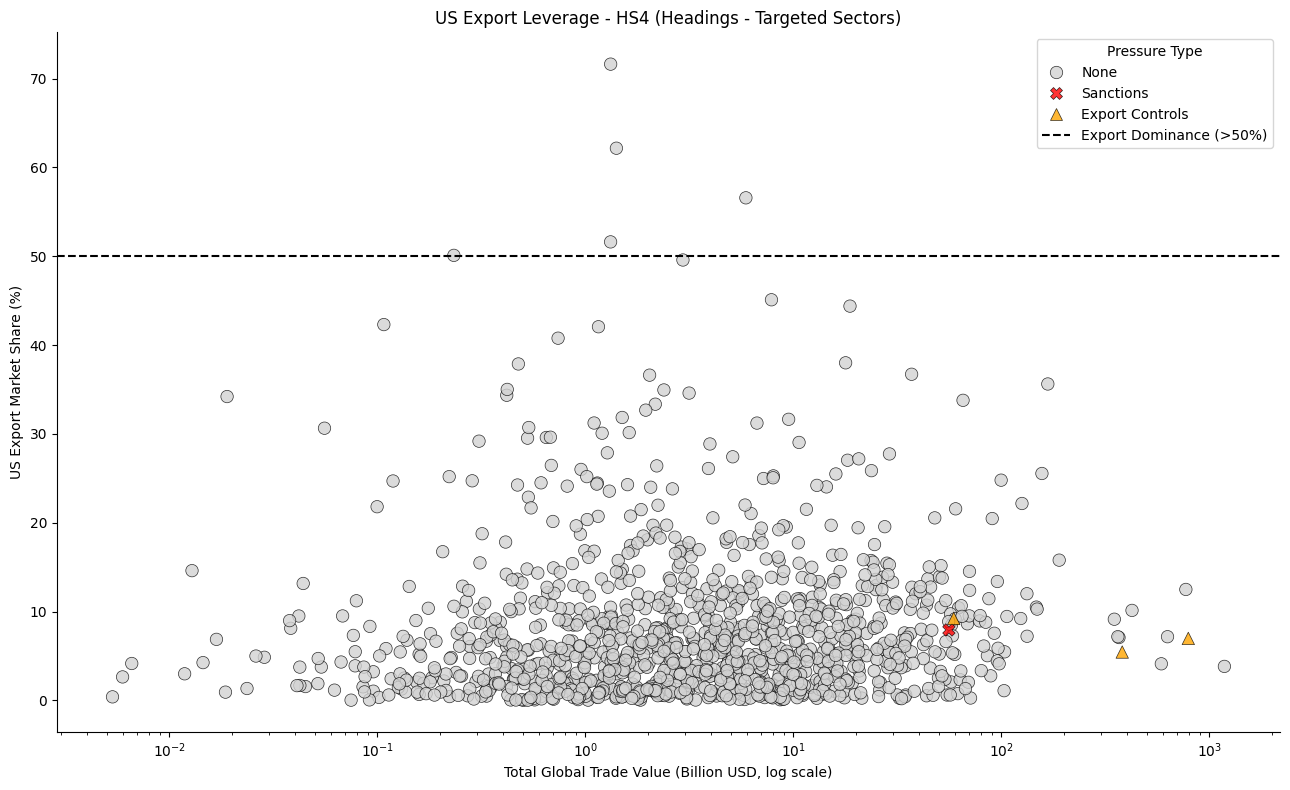


--- Aggregating and calculating HHI for: HS6 (Subheadings - Precise Chokepoints) ---
Displaying US Import Vulnerability plot (HS6_agg)


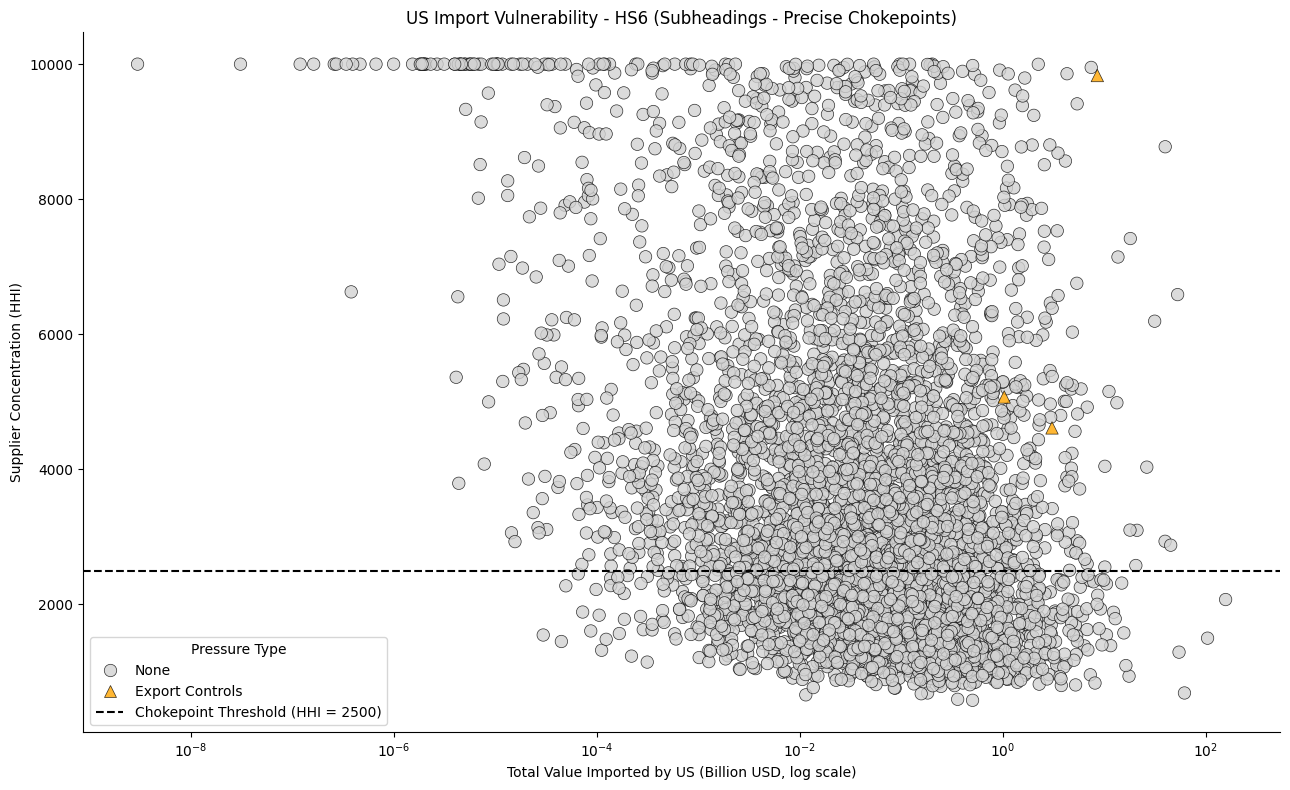

Displaying US Export Leverage plot (HS6_agg)


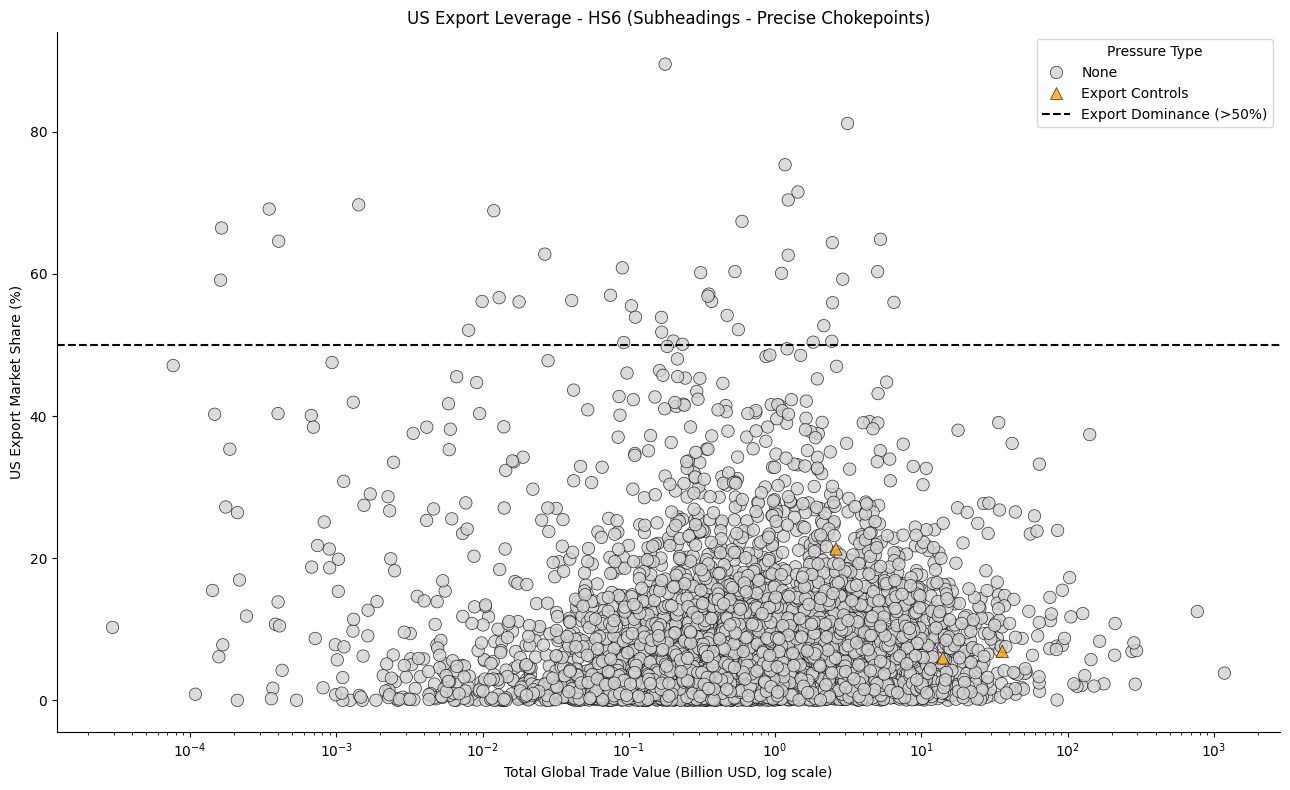

Execution complete.


In [20]:
"""
Analyze and visualize US trade vulnerability and export leverage.

This script processes global bilateral trade data (BACI) and LLM-extracted 
geoeconomic pressures to identify targeted product categories at the HS2, 
HS4, and HS6 levels. It calculates supplier concentration (HHI) for US imports 
and computes US export market shares to evaluate geoeconomic leverage.
"""


def extract_codes_by_type(pressure_df, prefix):
    """
    Extract HS2, HS4, and HS6 codes targeted by a specific measure type.

    Args:
        pressure_df (pd.DataFrame): Processed geoeconomic pressures.
        prefix (str): Measure prefix (e.g., 'tariffs', 'sanctions', 'exports').

    Returns:
        tuple: Three sets containing HS2, HS4, and HS6 codes respectively.
    """
    codes_2, codes_4, codes_6 = set(), set(), set()
    effect_col = f"{prefix}_effect_any"
    
    if effect_col in pressure_df.columns:
        filtered_df = pressure_df[pressure_df[effect_col] == 1]
    elif 'global_effect_any' in pressure_df.columns:
        filtered_df = pressure_df[pressure_df['global_effect_any'] == 1]
    else:
        filtered_df = pressure_df
        
    cols = [c for c in filtered_df.columns if c.startswith(prefix) and 'hs_' in c and 'explanation' not in c]
    
    for col in cols:
        vals = filtered_df[col].dropna().astype(str).str.strip()
        for v_item in vals:
            if v_item.lower() not in ['nan', 'none', 'null', '']:
                for code_part in v_item.split(','):
                    match = re.search(r'(\d+[\.\d]*)', code_part)
                    if match:
                        raw_code = match.group(1).replace('.', '')
                        if len(raw_code) == 1:
                            raw_code = '0' + raw_code
                        if len(raw_code) == 2:
                            codes_2.add(raw_code)
                        elif 3 <= len(raw_code) <= 4:
                            codes_4.add(raw_code.zfill(4))
                        elif len(raw_code) >= 5:
                            codes_6.add(raw_code[:6].zfill(6))
                            
    return codes_2, codes_4, codes_6


def determine_status(code, set_tariffs, set_sanctions, set_exports):
    """
    Determine the pressure status of a specific trade code.

    Args:
        code (str): The HS code.
        set_tariffs (set): Codes under tariffs.
        set_sanctions (set): Codes under sanctions.
        set_exports (set): Codes under export controls.

    Returns:
        str: Categorized pressure status.
    """
    in_t = code in set_tariffs
    in_s = code in set_sanctions
    in_e = code in set_exports
    total = in_t + in_s + in_e
    
    if total > 1:
        return 'Multiple'
    elif in_t:
        return 'Tariffs'
    elif in_s:
        return 'Sanctions'
    elif in_e:
        return 'Export Controls'
    return 'None'


def analyze_us_trade_dynamics(baci_csv, countries_csv, pressure_csv):
    """
    Analyze and plot US import vulnerability and export leverage.

    Load and merge datasets, extract product codes from LLM audits,
    calculate market concentration indicators, and generate scatter
    plots for multiple HS aggregation scales.

    Args:
        baci_csv (str): Path to BACI trade data.
        countries_csv (str): Path to country codes mapping.
        pressure_csv (str): Path to LLM processed pressures.
    """
    print("Loading CSV files...")
    baci_df = pd.read_csv(baci_csv, encoding='latin-1')
    countries_df = pd.read_csv(countries_csv, encoding='latin-1')
    pressure_df = pd.read_csv(pressure_csv, encoding='utf-8')
    print("Loading complete.")

    pressure_df = pressure_df[pressure_df['mistral_audit_response'].notna()]
    pressure_df = pressure_df[
        ~pressure_df['mistral_audit_response'].astype(str).str.startswith('ERREUR')
    ]

    baci_df['k_str'] = baci_df['k'].astype(str).str.zfill(6)

    us_code_row = countries_df[countries_df['country_iso3'] == 'USA']
    us_code = us_code_row['country_code'].iloc[0] if not us_code_row.empty else 840

    print("Extracting customs codes from transcripts...")
    t_2, t_4, t_6 = extract_codes_by_type(pressure_df, 'tariffs')
    s_2, s_4, s_6 = extract_codes_by_type(pressure_df, 'sanctions')
    e_2, e_4, e_6 = extract_codes_by_type(pressure_df, 'exports')

    print(f"Codes found - Tariffs: HS2({len(t_2)}), HS4({len(t_4)}), HS6({len(t_6)})")
    print(f"Codes found - Sanctions: HS2({len(s_2)}), HS4({len(s_4)}), HS6({len(s_6)})")
    print(f"Codes found - Exports: HS2({len(e_2)}), HS4({len(e_4)}), HS6({len(e_6)})")

    aggregation_scales = [
        ('HS2 (Chapters - Entire Industries)', 2, t_2, s_2, e_2, 'HS2_agg'),
        ('HS4 (Headings - Targeted Sectors)', 4, t_4, s_4, e_4, 'HS4_agg'),
        ('HS6 (Subheadings - Precise Chokepoints)', 6, t_6, s_6, e_6, 'HS6_agg')
    ]

    palette_measures = {
        'None': 'lightgrey', 'Tariffs': 'blue', 
        'Sanctions': 'red', 'Export Controls': 'orange', 'Multiple': 'purple'
    }
    markers_measures = {
        'None': 'o', 'Tariffs': 's', 
        'Sanctions': 'X', 'Export Controls': '^', 'Multiple': 'D'
    }
    order_map = {
        'None': 0, 'Tariffs': 1, 'Sanctions': 2, 
        'Export Controls': 3, 'Multiple': 4
    }

    for title, level, set_t, set_s, set_e, file_suffix in aggregation_scales:
        print(f"\n--- Aggregating and calculating HHI for: {title} ---")
        baci_df['k_agg'] = baci_df['k_str'].str.slice(0, level)
        
        us_imports = baci_df[baci_df['j'] == us_code].copy()
        us_imports_grouped = us_imports.groupby(['k_agg', 'i'])['v'].sum().reset_index()
        us_import_totals = us_imports_grouped.groupby('k_agg')['v'].sum().reset_index(name='us_total_import')
        
        us_import_hhi_df = us_imports_grouped.groupby('k_agg')['v'].apply(calculate_hhi).reset_index(name='us_import_hhi')
        base_us_import = us_import_totals.merge(us_import_hhi_df, on='k_agg')
        base_us_import['v_billion'] = base_us_import['us_total_import'] / 1e6
        
        global_exports = baci_df.groupby('k_agg')['v'].sum().reset_index(name='global_total_export')
        us_exports = baci_df[baci_df['i'] == us_code].groupby('k_agg')['v'].sum().reset_index(name='us_export')
        base_us_export = global_exports.merge(us_exports, on='k_agg', how='left').fillna({'us_export': 0})
        base_us_export['us_export_share_%'] = (base_us_export['us_export'] / base_us_export['global_total_export']) * 100
        base_us_export['global_v_billion'] = base_us_export['global_total_export'] / 1e6

        base_us_import['Status'] = base_us_import['k_agg'].apply(
            lambda x: determine_status(x, set_t, set_s, set_e)
        )
        base_us_import['sort_key'] = base_us_import['Status'].map(order_map)
        base_us_import = base_us_import.sort_values(by='sort_key')
        
        print(f"Displaying US Import Vulnerability plot ({file_suffix})")
        plt.figure(figsize=(13, 8))
        sns.scatterplot(
            data=base_us_import, x='v_billion', y='us_import_hhi', 
            hue='Status', style='Status', palette=palette_measures, 
            markers=markers_measures, alpha=0.8, s=80, 
            edgecolor='black', linewidth=0.5
        )
        plt.axhline(2500, color='black', linestyle='--', label='Chokepoint Threshold (HHI = 2500)')
        plt.xscale('log')
        plt.title(f'US Import Vulnerability - {title}')
        plt.xlabel('Total Value Imported by US (Billion USD, log scale)')
        plt.ylabel('Supplier Concentration (HHI)')
        plt.legend(title='Pressure Type')
        sns.despine()
        plt.tight_layout()
        plt.savefig(f'us_import_vuln_{file_suffix}.png', dpi=300)
        plt.show()
        plt.close()

        base_us_export['Status'] = base_us_export['k_agg'].apply(
            lambda x: determine_status(x, set_t, set_s, set_e)
        )
        base_us_export['sort_key'] = base_us_export['Status'].map(order_map)
        base_us_export = base_us_export.sort_values(by='sort_key')
        
        print(f"Displaying US Export Leverage plot ({file_suffix})")
        plt.figure(figsize=(13, 8))
        sns.scatterplot(
            data=base_us_export, x='global_v_billion', y='us_export_share_%', 
            hue='Status', style='Status', palette=palette_measures, 
            markers=markers_measures, alpha=0.8, s=80, 
            edgecolor='black', linewidth=0.5
        )
        plt.axhline(50, color='black', linestyle='--', label='Export Dominance (>50%)')
        plt.xscale('log')
        plt.title(f'US Export Leverage - {title}')
        plt.xlabel('Total Global Trade Value (Billion USD, log scale)')
        plt.ylabel('US Export Market Share (%)')
        plt.legend(title='Pressure Type')
        sns.despine()
        plt.tight_layout()
        plt.savefig(f'us_export_leverage_{file_suffix}.png', dpi=300)
        plt.show()
        plt.close()

    print("Execution complete.")

analyze_us_trade_dynamics(
    baci_csv='../Data/BACI_HS17_Y2018_V202601.csv',
    countries_csv='../Data/country_codes_V202601.csv',
    pressure_csv='../Data/results_final_flattened_0.csv'
)